## Prédiction des prix immobiliers - LA PLACE IMMO

### Notebook 1 : Analyse Exploratoire des données (EDA)

In [150]:
# Importation des packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import logging

# Configuration du logger
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [145]:
# Repertoire de travail
os.chdir(r'C:\Users\HP\Desktop\A_2026\Semestre2\Machine learning\Projet ML') 

In [119]:
# Chargement des données et taille de la base
data = pd.read_csv('data/raw/train.csv')

In [120]:
# Supression de la colonne Id puisqu'elle n'est pas nécessaire
data.drop("Id", axis = 1, inplace = True)

In [121]:
# Taille des bases
print(f"data : {data.shape[0]} lignes, {data.shape[1]} colonnes")

data : 1460 lignes, 80 colonnes


In [122]:
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [123]:
data.describe(include="all")

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,5,NaN,NaN,2,2,4,4,2,5,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [124]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [125]:
# Variables quantitatives sans le target et l'iditifiant

quantitative = [f for f in data.columns if data.dtypes[f] != 'object']
quantitative.remove('SalePrice')
print(f"Nombre de variables quantitatives : {len(quantitative)}")
quantitative

Nombre de variables quantitatives : 36


['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [118]:
data['OverallCond'].describe()

count    1460.000000
mean        5.575342
std         1.112799
min         1.000000
25%         5.000000
50%         5.000000
75%         6.000000
max         9.000000
Name: OverallCond, dtype: float64

In [92]:
# Variables qualitatives

qualitative = [f for f in train.columns if train.dtypes[f] == 'object']
print(f"Nombre de variables qualitatives : {len(qualitative)}")
qualitative

Nombre de variables qualitatives : 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

## Distribution de la variable cible Saleprice

In [128]:
# Description de la variable cible
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [126]:
print(f"Skewness originale : {data['SalePrice'].skew():.2f}")

Skewness originale : 1.88


Text(0.5, 0, 'log1p(SalePrice)')

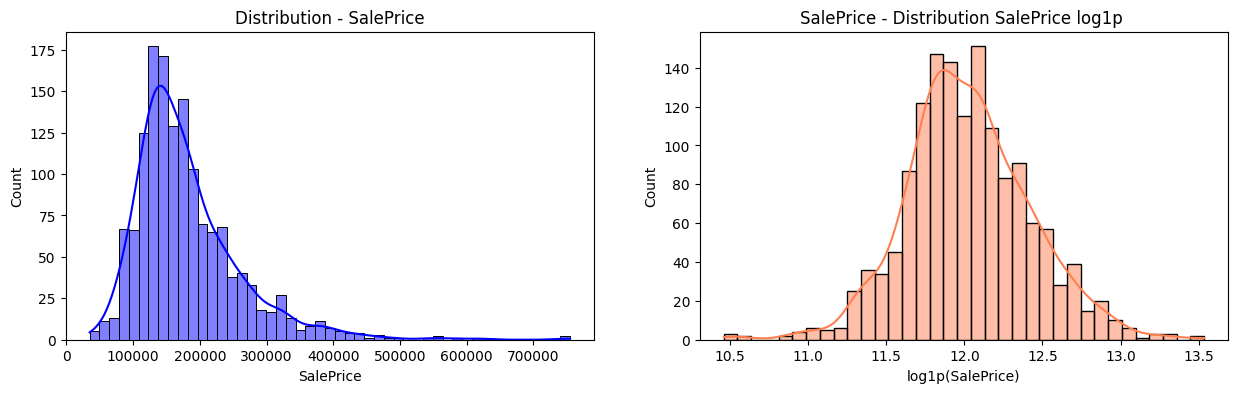

In [129]:
# Distribution de la variable cible : original vs transformation log

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
sns.histplot(data["SalePrice"], color='b', kde=True, ax=axes[0])
axes[0].set_title('Distribution - SalePrice')

sns.histplot(np.log1p(train['SalePrice']),  color='coral', kde=True, ax=axes[1])
axes[1].set_title('SalePrice - Distribution SalePrice log1p ')
axes[1].set_xlabel('log1p(SalePrice)')

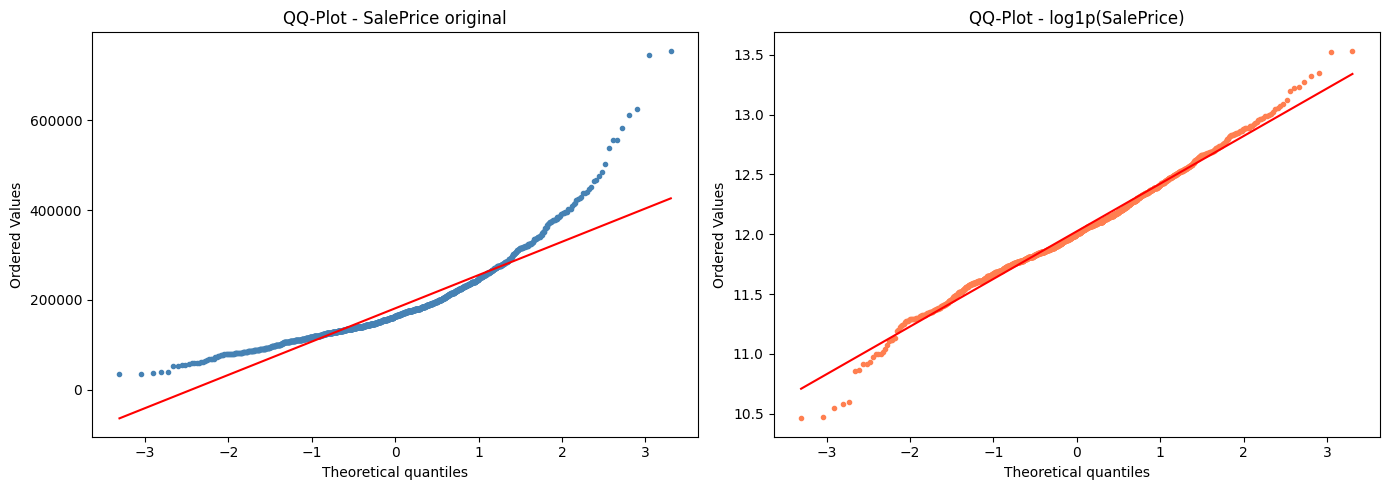

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Avant transformation ---
stats.probplot(train['SalePrice'], plot=axes[0])
axes[0].set_title('QQ-Plot - SalePrice original')
axes[0].get_lines()[0].set(color='steelblue', markersize=3)
axes[0].get_lines()[1].set(color='red')

# --- Après transformation ---
stats.probplot(np.log1p(data['SalePrice']), plot=axes[1])
axes[1].set_title('QQ-Plot - log1p(SalePrice)')
axes[1].get_lines()[0].set(color='coral', markersize=3)
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()
plt.show()

In [131]:

print(f"Skewness originale  : {data['SalePrice'].skew():.4f}")
print(f"Kurtosis originale  : {data['SalePrice'].kurt():.4f}")
print("---")
print(f"Skewness après log  : {np.log1p(data['SalePrice']).skew():.4f}")
print(f"Kurtosis après log  : {np.log1p(data['SalePrice']).kurt():.4f}")

Skewness originale  : 1.8829
Kurtosis originale  : 6.5363
---
Skewness après log  : 0.1213
Kurtosis après log  : 0.8095


### Correlations plus fortes

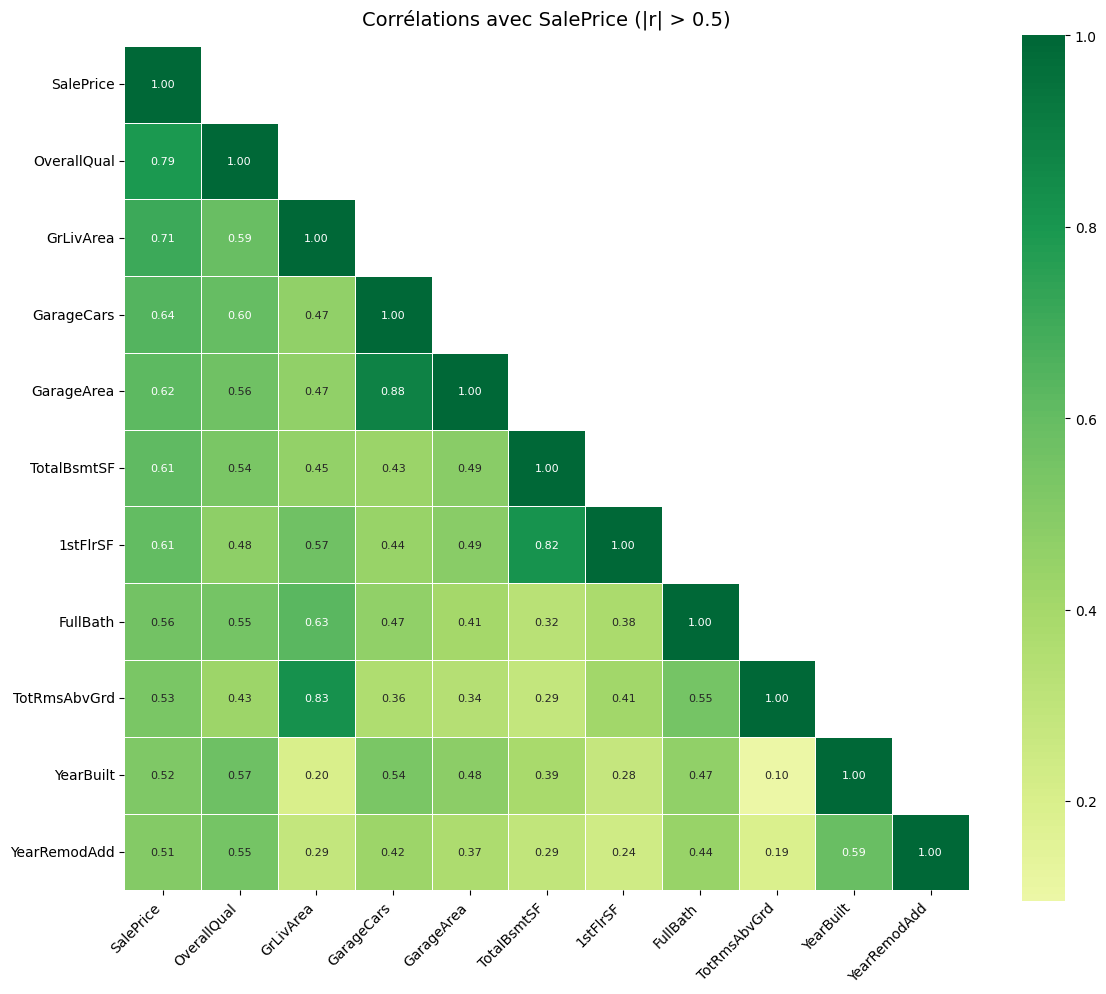

In [103]:
# Correlation des variables numériques avec SalePrice 

# 1. Sélectionner uniquement les variables numériques dans la base train
numVar = data.select_dtypes(include=[np.number])

# 2. Matrice de corrélations (équivalent de use="pairwise.complete.obs")
cor_numVar = numVar.corr(method='pearson')

# 3. Trier par corrélation décroissante avec SalePrice
cor_sorted = cor_numVar['SalePrice'].sort_values(ascending=False)

# 4. Garder uniquement les corrélations élevées (|r| > 0.5)
CorHigh = cor_sorted[abs(cor_sorted) > 0.5].index.tolist()

# 5. Filtrer la matrice
cor_numVar_high = cor_numVar.loc[CorHigh, CorHigh]

# 6. Visualisation (équivalent de corrplot.mixed)
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(cor_numVar_high, dtype=bool), k=1)  # triangle supérieur

sns.heatmap(
    cor_numVar_high,
    annot=True,           # affiche les valeurs numériques
    fmt=".2f",            # 2 décimales
    cmap="RdYlGn",        # rouge → jaune → vert
    center=0,
    mask=mask,            # cache le triangle supérieur (comme corrplot.mixed)
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8}
)

ax.set_title("Corrélations avec SalePrice (|r| > 0.5)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

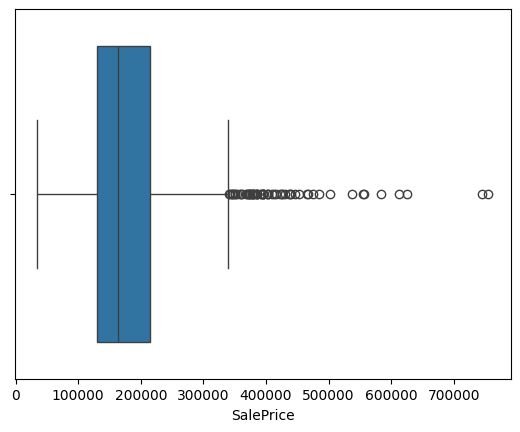

In [132]:
sns.boxplot(data["SalePrice"], orient="h");

## Preprocessing

### Valeurs manquantes 

In [133]:
# Calcul des valeurs manquantes
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(2)

# Tableau récapitulatif
missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing,
    'Pourcentage (%)'    : missing_pct,
    'Type'               : data[missing.index].dtypes
})

print(f"Nombre de variables avec NaN : {len(missing_df)}")
print(missing_df)

Nombre de variables avec NaN : 19
              Valeurs manquantes  Pourcentage (%)     Type
PoolQC                      1453            99.52   object
MiscFeature                 1406            96.30   object
Alley                       1369            93.77   object
Fence                       1179            80.75   object
MasVnrType                   872            59.73   object
FireplaceQu                  690            47.26   object
LotFrontage                  259            17.74  float64
GarageType                    81             5.55   object
GarageYrBlt                   81             5.55  float64
GarageFinish                  81             5.55   object
GarageQual                    81             5.55   object
GarageCond                    81             5.55   object
BsmtFinType2                  38             2.60   object
BsmtExposure                  38             2.60   object
BsmtFinType1                  37             2.53   object
BsmtCond              

In [134]:
# Variables catégorielles ayant des NaN
cat_with_nan = [col for col in data.columns 
                if data[col].isnull().any() 
                and data[col].dtype == 'object']

print(f"Nombre de variables catégorielles avec NaN : {len(cat_with_nan)}")
print(f"Variables : {cat_with_nan}")

Nombre de variables catégorielles avec NaN : 16
Variables : ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [135]:
for col in cat_with_nan:
    
 cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    print("=" * 60)
    print(f"Variable  : {col}")
    print(f"NaN       : {data[col].isnull().sum()} ({data[col].isnull().mean()*100:.2f}%)")
    print(f"Modalités ({data[col].nunique()}) : ")
    print(data[col].value_counts(dropna=False))
    print()

Variable  : MSZoning
NaN       : 0 (0.00%)
Modalités (5) : 
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Variable  : Street
NaN       : 0 (0.00%)
Modalités (2) : 
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Variable  : Alley
NaN       : 1369 (93.77%)
Modalités (2) : 
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Variable  : LotShape
NaN       : 0 (0.00%)
Modalités (4) : 
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Variable  : LandContour
NaN       : 0 (0.00%)
Modalités (4) : 
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Variable  : Utilities
NaN       : 0 (0.00%)
Modalités (2) : 
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Variable  : LotConfig
NaN       : 0 (0.00%)
Modalités (5) : 
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name

In [140]:
# les NaN des variables catégorielles ci dessous correspondent à une absente de la modalite (description des données)
cols_none = [
    "PoolQC", 
    "MiscFeature", 
    "Fence", 
    "FireplaceQu",
    "Alley",          # pas d'allée
    "GarageType",     # pas de garage
    "GarageFinish",   # pas de garage
    "GarageQual",     # pas de garage
    "GarageCond",     # pas de garage
    "BsmtQual",       # pas de sous-sol
    "BsmtCond",       # pas de sous-sol
    "BsmtExposure",   # pas de sous-sol
    "BsmtFinType1",   # pas de sous-sol
    "BsmtFinType2",   # pas de sous-sol
    "MasVnrType"      # pas de maçonnerie
]

data[cols_none] = data[cols_none].fillna("None")

## Une seule valeur manquante pour la var Electrical (éventuelle imputation par le mode)

### Encodage des variables catégorielles

In [149]:
data["MSSubClass"]

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1460, dtype: int64